# 02 - Análise Exploratória de Dados

## 1. Importação das bibliotecas e leitura dos dados


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(
    style="whitegrid",
    palette="deep"
)

BASE_DIR = Path("..")
GOLD_DIR = BASE_DIR / "data" / "gold"

DATASET_PATH = GOLD_DIR / "gold_dataset_enriquecido.parquet"

df = pd.read_parquet(DATASET_PATH)

print("Dataset carregado com sucesso.")
print("Shape:", df.shape)

Dataset carregado com sucesso.
Shape: (57782, 35)


In [2]:
print(f"Total de Linhas -> {df.shape[0]}")
print(f"Total de Colunas -> {df.shape[1]}")

Total de Linhas -> 57782
Total de Colunas -> 35


In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 57782 entries, 0 to 57781
Data columns (total 35 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   ano                                 57782 non-null  Int64  
 1   id_municipio                        57782 non-null  string 
 2   id_municipio_nome                   57782 non-null  string 
 3   id_escola                           57782 non-null  string 
 4   id_aluno                            57782 non-null  string 
 5   caderno                             57782 non-null  int64  
 6   serie                               57782 non-null  string 
 7   rede                                57782 non-null  string 
 8   presenca                            57782 non-null  string 
 9   preenchimento_caderno               57782 non-null  string 
 10  alfabetizado                        57782 non-null  string 
 11  proficiencia                        48026 non-null  

### Duplicidades

In [5]:
duplicidades = df.duplicated(subset=["ano", "id_aluno"]).sum()

print(f"Duplicidades por Ano + Id_aluno -> {duplicidades}")

Duplicidades por Ano + Id_aluno -> 0


In [6]:
print(f"Linhas completamente duplicadas -> {df.duplicated().sum()}")

Linhas completamente duplicadas -> 0


### Cobertura Temporal

In [7]:
print(df["ano"].value_counts().sort_index())

ano
2023    28295
2024    29487
Name: count, dtype: Int64


### Validação do target

In [10]:
print(f"Valores únicos do target -> {df['alfabetizado'].unique()}")

print(f"\nDistribuição:")
print(df['alfabetizado'].value_counts())

print("\nDistribuição em Percentual:")
print(df['alfabetizado'].value_counts(normalize=True).mul(100).round(2))

Valores únicos do target -> <ArrowStringArray>
['Não', 'Sim']
Length: 2, dtype: string

Distribuição:
alfabetizado
Não    29535
Sim    28247
Name: count, dtype: int64[pyarrow]

Distribuição em Percentual:
alfabetizado
Não    51.11
Sim    48.89
Name: proportion, dtype: double[pyarrow]


### Resumo de valores ausentes

In [11]:
resumo_final = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "pct_nulos": (df.isna().mean() * 100).round(2),
    "valores_unicos": df.nunique(dropna=True)
})

display(resumo_final)

,tipo,nulos,pct_nulos,valores_unicos
ano,Int64,0,0.00,2
id_municipio,string,0,0.00,4591
id_municipio_nome,string,0,0.00,4397
id_escola,string,0,0.00,24346
id_aluno,string,0,0.00,57449
caderno,int64,0,0.00,4
serie,string,0,0.00,1
rede,string,0,0.00,2
presenca,string,0,0.00,2
preenchimento_caderno,string,0,0.00,2


## 2.7 Definição das variáveis utilizadas na análise

Após a avaliação da qualidade dos dados, algumas variáveis foram removidas da base utilizada nas análises principais.

As variáveis `meta_municipio_ano` e `meta_uf_ano` apresentam elevada proporção de valores ausentes. A variável `proficiencia` foi excluída por apresentar potencial vazamento de informação em relação à variável alvo `alfabetizado`.

As variáveis `peso_aluno` e `percentual_participacao` também foram removidas por não serem consideradas essenciais para o objetivo principal da modelagem.

O dataset original foi preservado, sendo criada uma cópia específica para as etapas de EDA e modelagem.

In [12]:
colunas_remover = ["meta_municipio_ano", "meta_uf_ano", "proficiencia", "peso_aluno", "percentual_participacao"]

df_eda = df.drop(columns=colunas_remover).copy()

print("Shape original:", df.shape)
print("Shape após remoção:", df_eda.shape)

print("\nColunas removidas:")
for coluna in colunas_remover:
    print("-", coluna)

Shape original: (57782, 35)
Shape após remoção: (57782, 30)

Colunas removidas:
- meta_municipio_ano
- meta_uf_ano
- proficiencia
- peso_aluno
- percentual_participacao


In [13]:
linhas_antes = len(df_eda)

df_eda_sem_nulos = df_eda.dropna().copy()

linhas_depois = len(df_eda_sem_nulos)

print("Linhas antes:", linhas_antes)
print("Linhas depois:", linhas_depois)
print("Linhas removidas:", linhas_antes - linhas_depois)
print(
    "Percentual removido:",
    round((linhas_antes - linhas_depois) / linhas_antes * 100, 2),
    "%"
)

Linhas antes: 57782
Linhas depois: 57712
Linhas removidas: 70
Percentual removido: 0.12 %


In [16]:
df_eda = df_eda.dropna()
print(f"Total de nulos -> {df_eda.isna().sum().sum()}")

Total de nulos -> 0


## 3. Análise da variável alvo

A variável `alfabetizado` representa o desfecho que será posteriormente utilizado como target na etapa de modelagem supervisionada.

Nesta seção será avaliada sua distribuição geral, verificando o equilíbrio entre as classes e possíveis diferenças ao longo do tempo.

In [25]:
qtd_classes = df_eda['alfabetizado'].value_counts()
percentual_classes = df_eda['alfabetizado'].value_counts(normalize=True).round(2) * 100

resumo_classes = pd.DataFrame({
    "quantidade": qtd_classes,
    "percentual": percentual_classes
})

resumo_classes

,quantidade,percentual
alfabetizado,,
Não,29468,51.0
Sim,28244,49.0


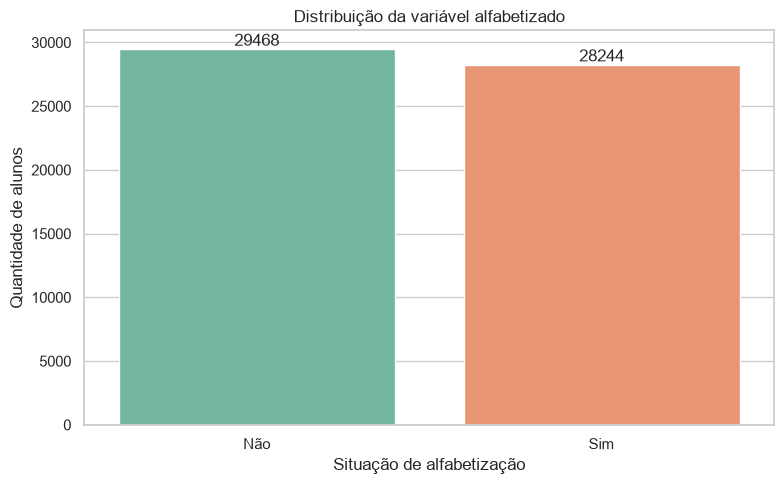

In [20]:
plt.figure(figsize=(8,5))

ax = sns.countplot(df_eda, x='alfabetizado', hue='alfabetizado', legend=False, palette='Set2')

plt.title("Distribuição da variável alfabetizado")
plt.xlabel("Situação de alfabetização")
plt.ylabel("Quantidade de alunos")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [21]:
alfabetizacao_ano = pd.crosstab(
    df_eda['ano'], df_eda['alfabetizado'], normalize="index"
).mul(100).round(2)

alfabetizacao_ano

alfabetizado,Não,Sim
ano,,
2023,51.77,48.23
2024,50.38,49.62


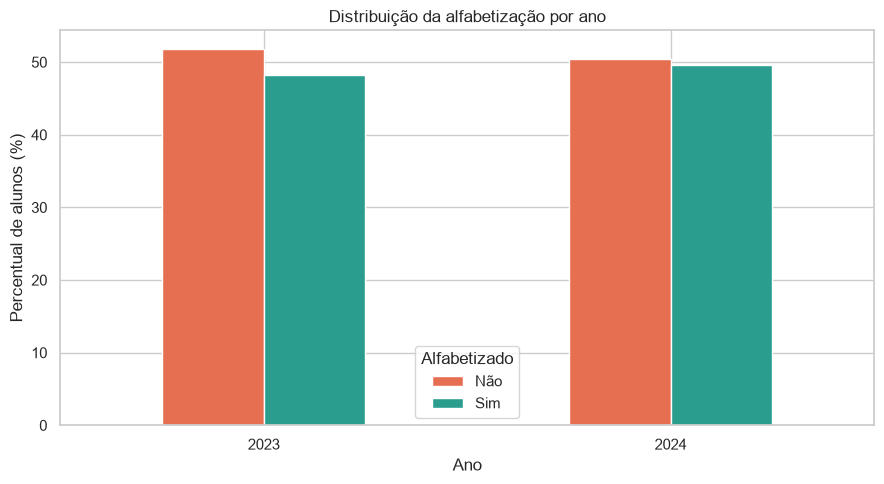

In [22]:
alfabetizacao_ano.plot(
    kind="bar",
    figsize=(9, 5),
    color=["#e76f51", "#2a9d8f"]
)

plt.title("Distribuição da alfabetização por ano")
plt.xlabel("Ano")
plt.ylabel("Percentual de alunos (%)")
plt.xticks(rotation=0)
plt.legend(title="Alfabetizado")

plt.tight_layout()
plt.show()

## Variáveis Numéricas

In [26]:
var_numericas = df_eda.select_dtypes(include="number").columns.tolist()

var_numericas

['ano',
 'caderno',
 'pib_per_capita',
 'populacao_2022',
 'area_km2',
 'densidade_demografica',
 'qtd_escolas_censo',
 'prop_escolas_rurais',
 'prop_escolas_agua_potavel',
 'prop_escolas_esgoto_rede',
 'prop_escolas_biblioteca_leitura',
 'prop_escolas_lab_informatica',
 'prop_escolas_internet',
 'prop_escolas_internet_aprendizagem',
 'prop_escolas_banda_larga',
 'prop_escolas_rampas_acessibilidade',
 'media_alunos_turma_fund_ai',
 'media_alunos_docente_fund_ai',
 'media_prop_salas_climatizadas']

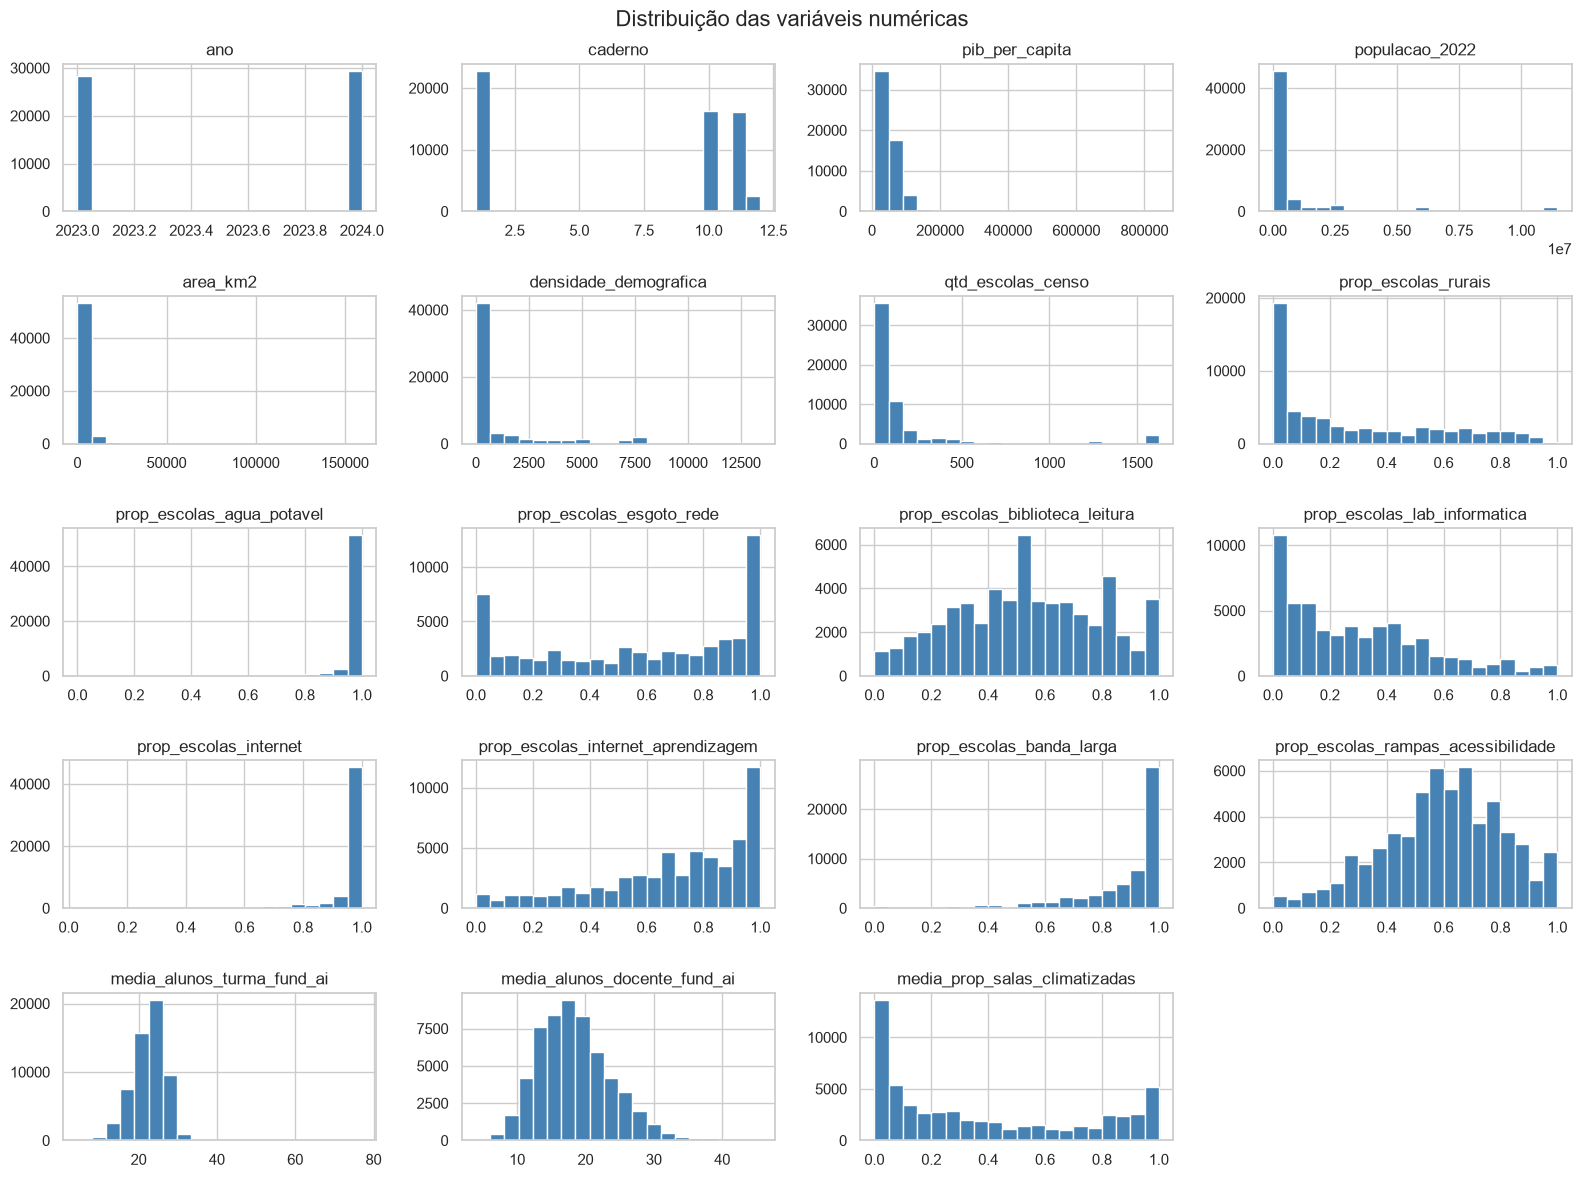

In [27]:
df_eda[var_numericas].hist(
    figsize=(16,12),
    bins=20,
    color="steelblue"
)
plt.suptitle("Distribuição das variáveis numéricas", fontsize=16)
plt.tight_layout()
plt.show()

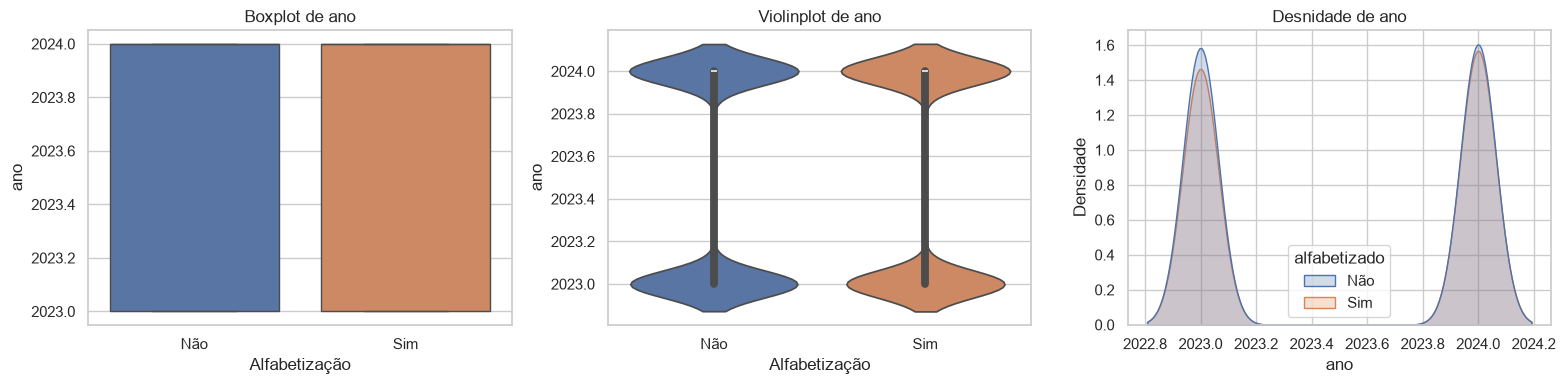

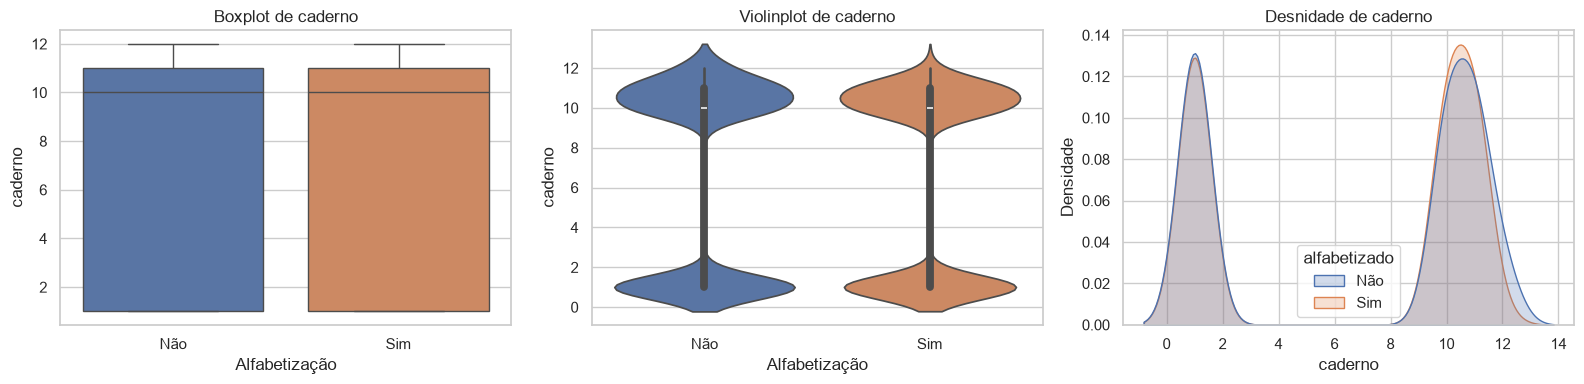

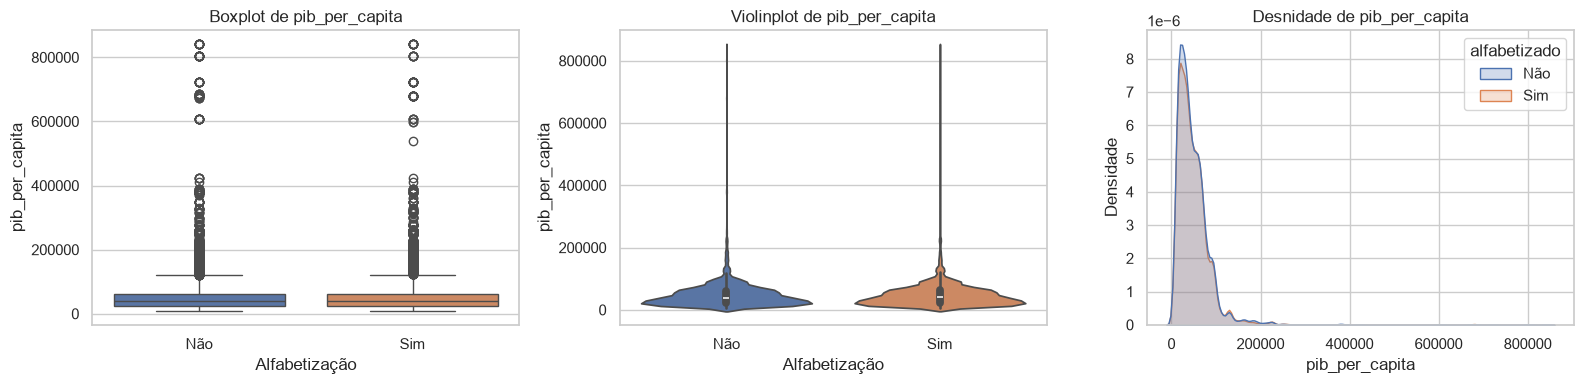

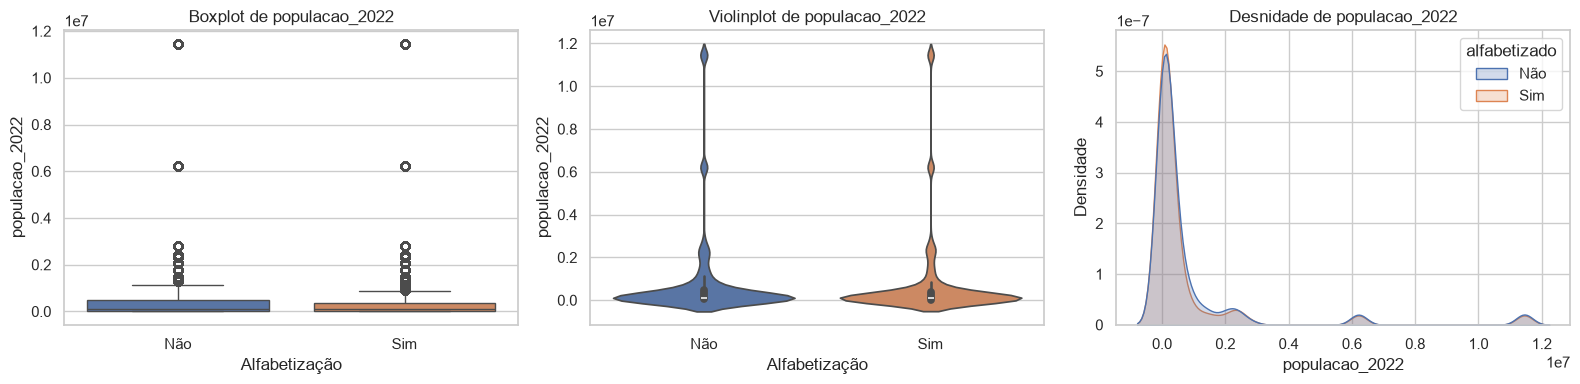

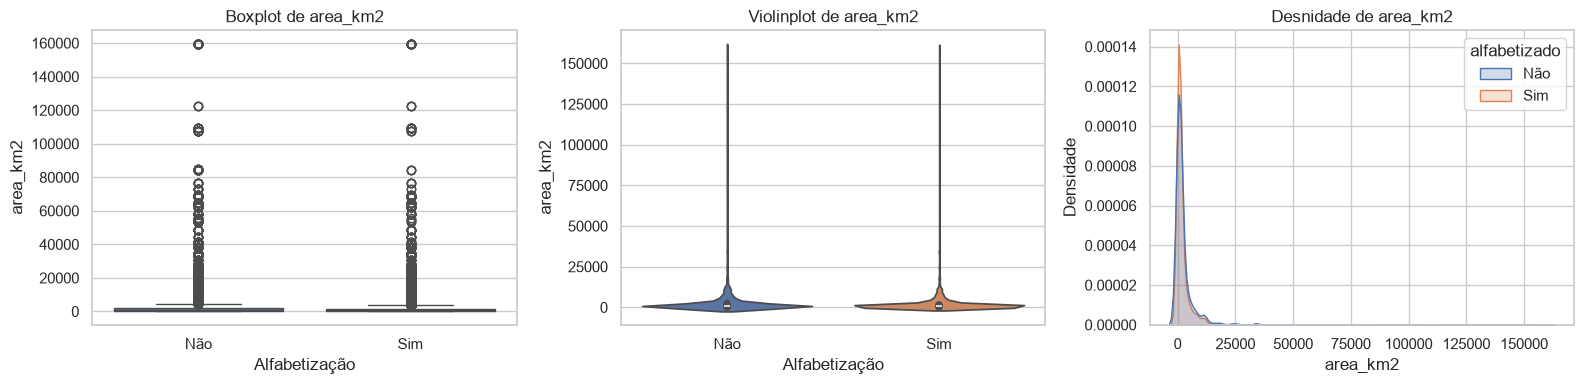

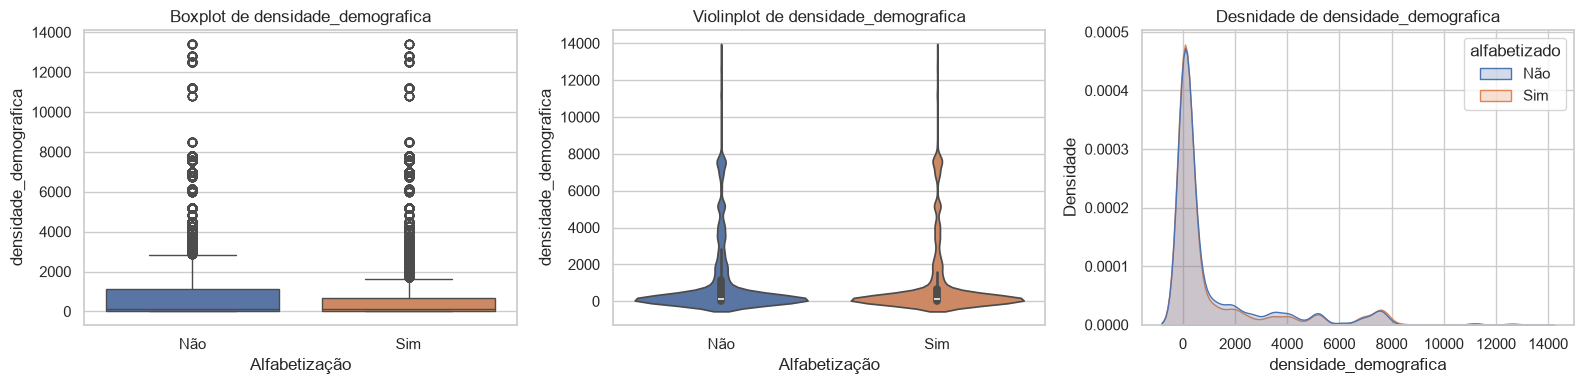

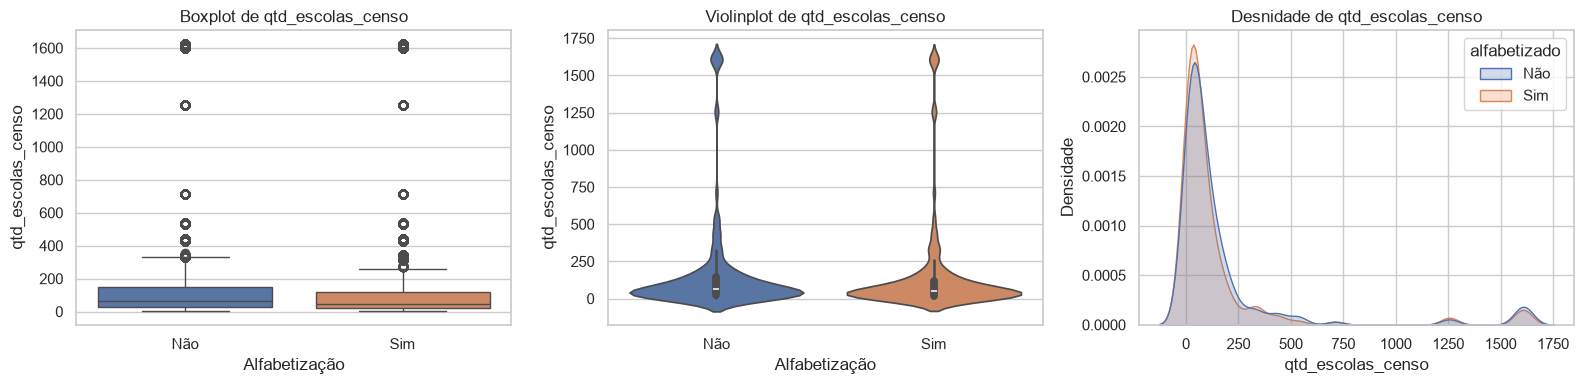

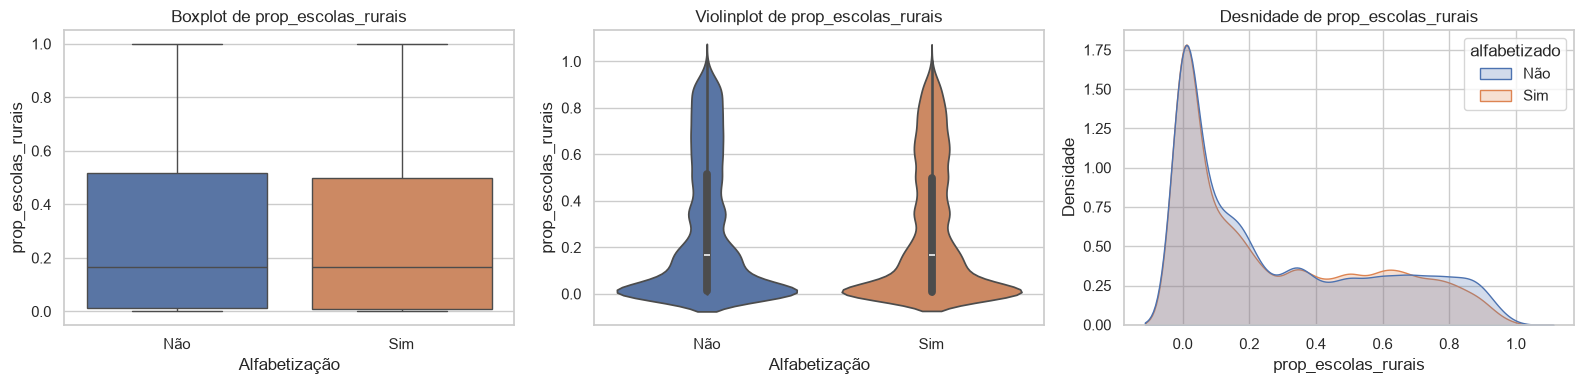

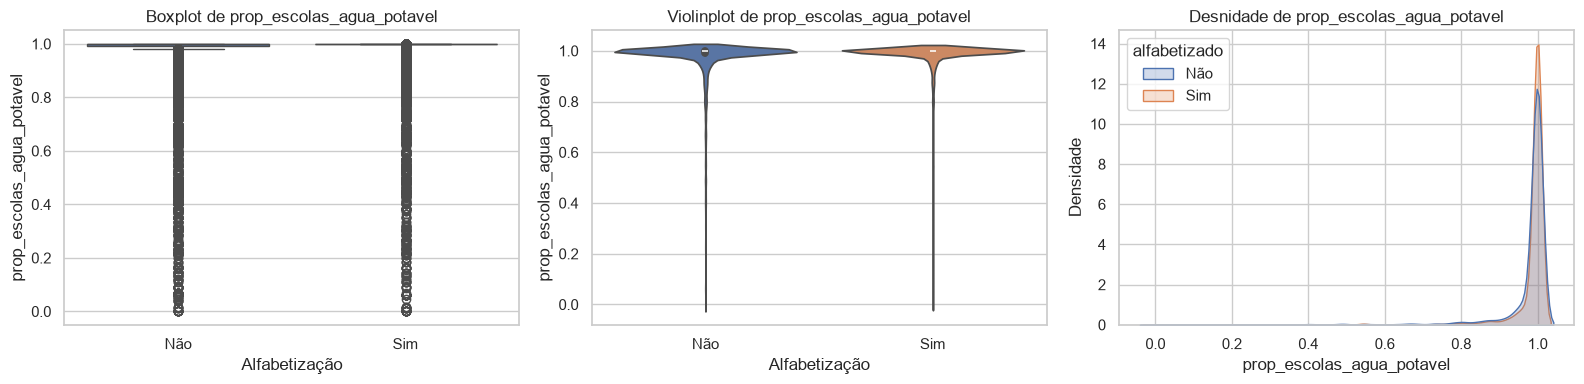

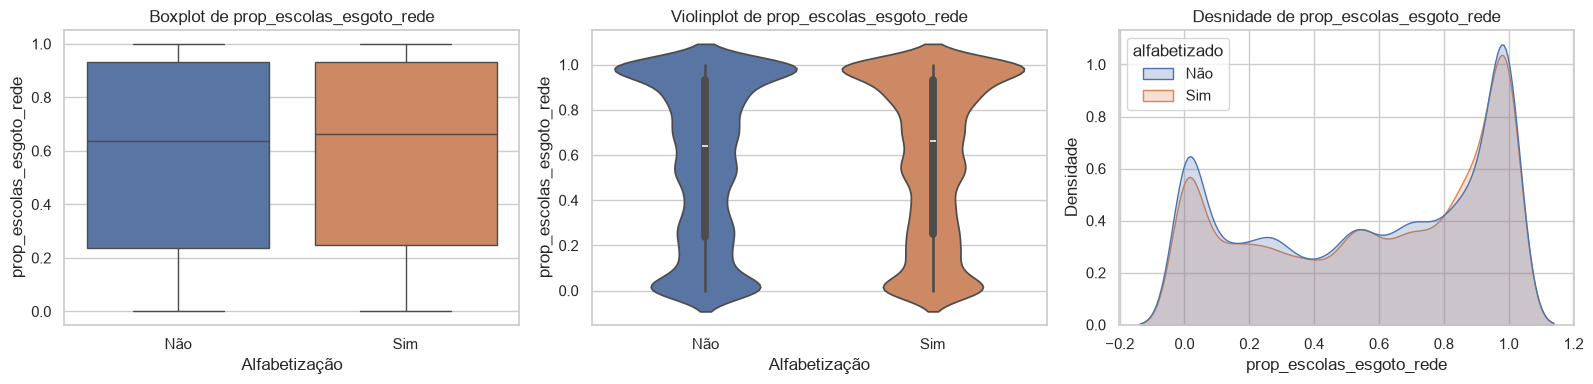

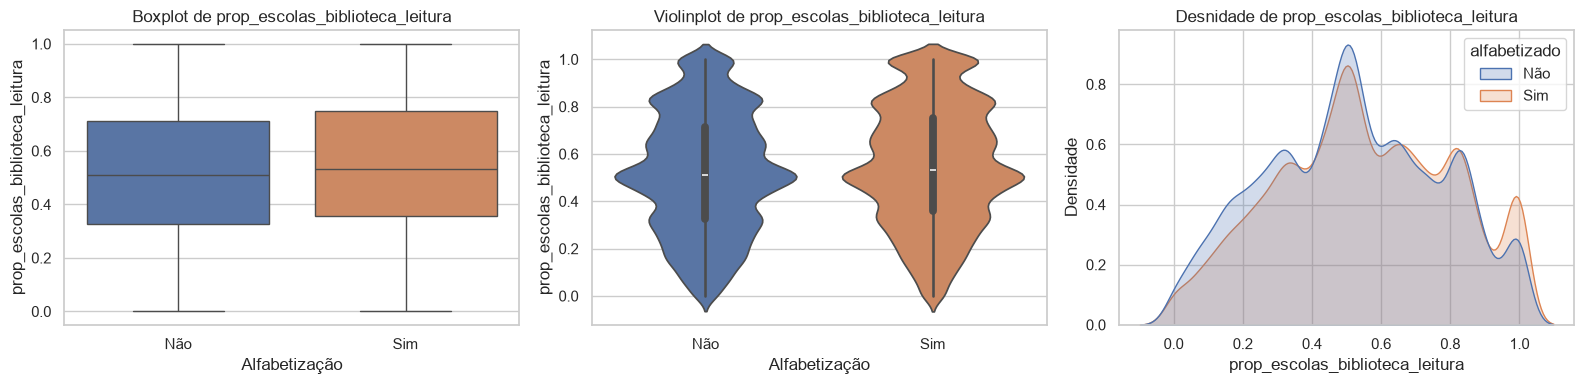

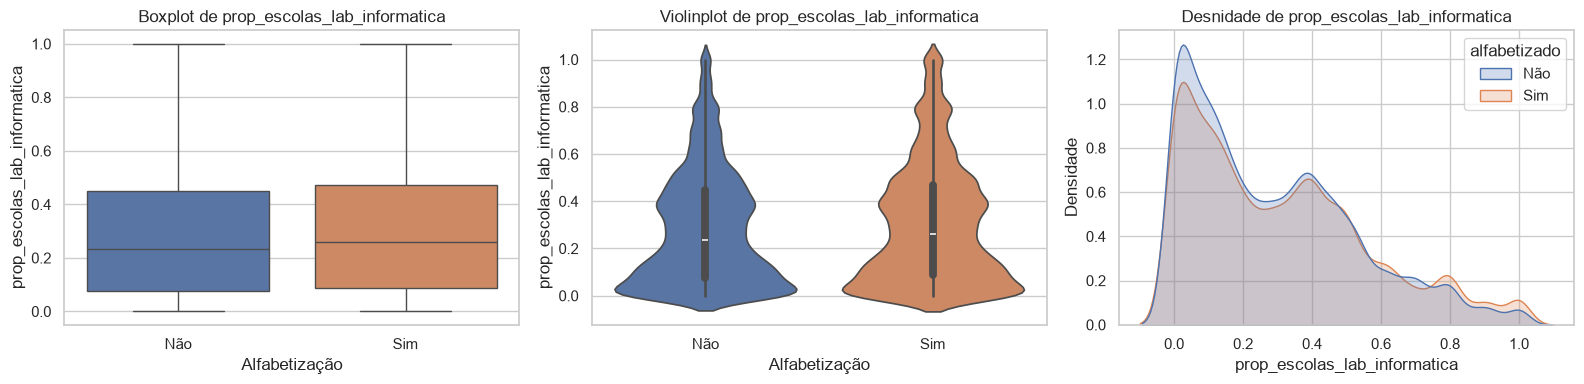

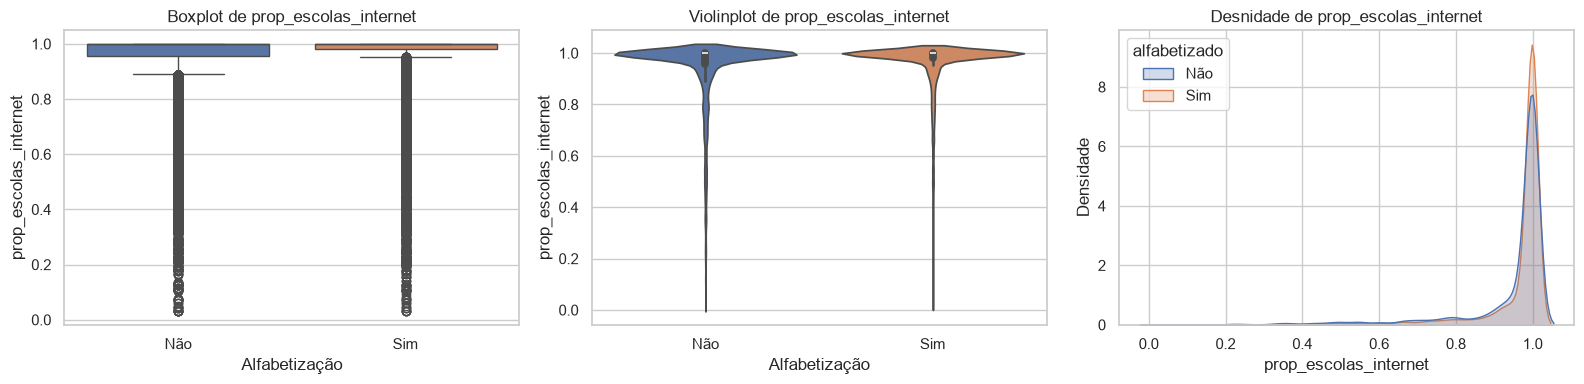

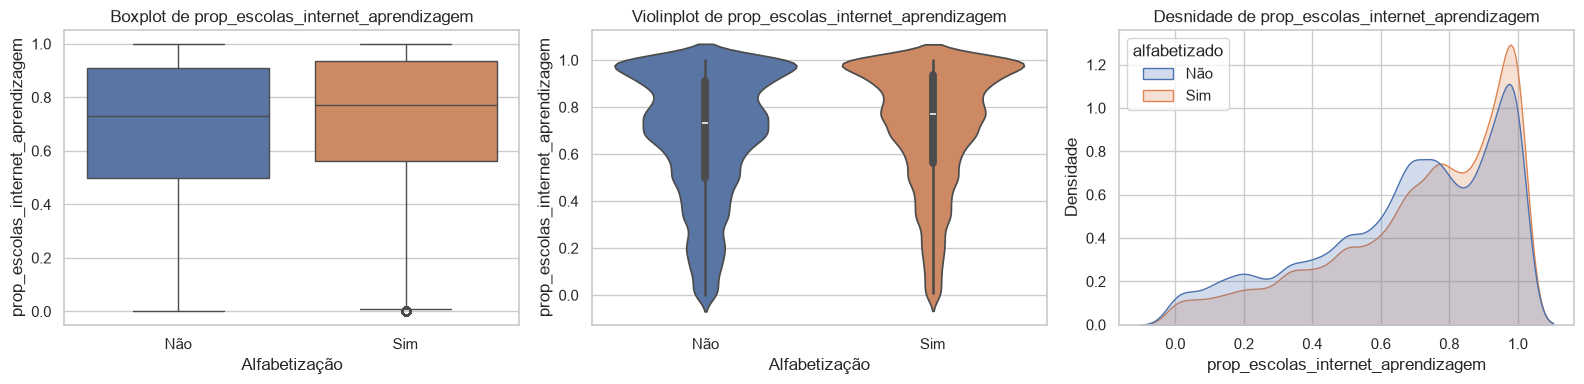

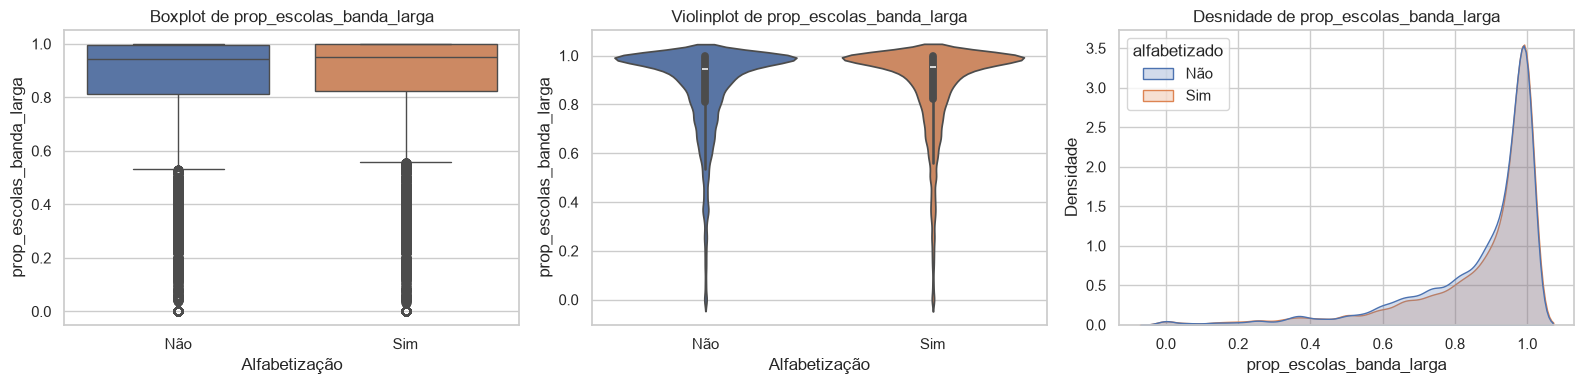

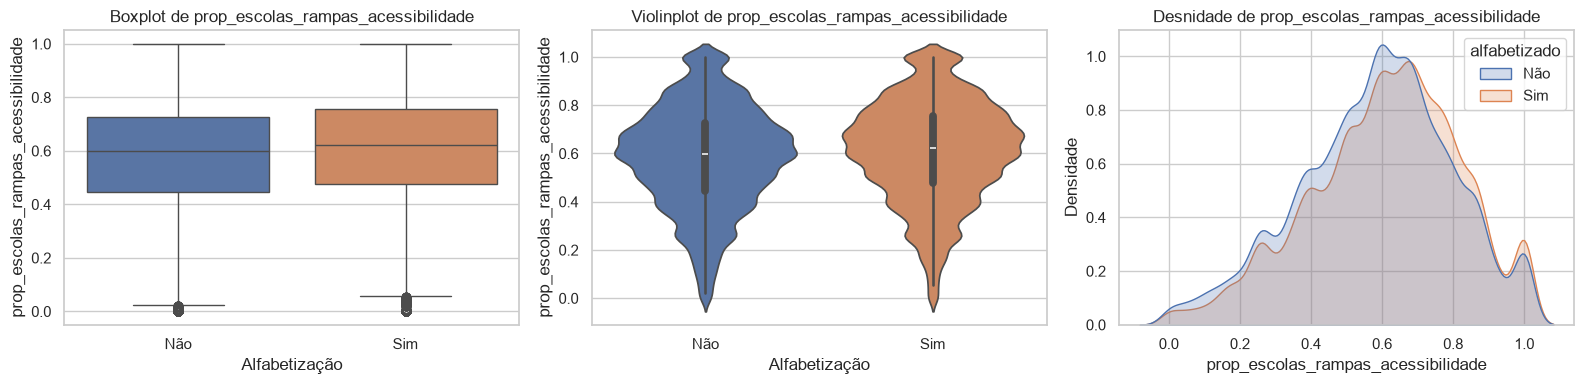

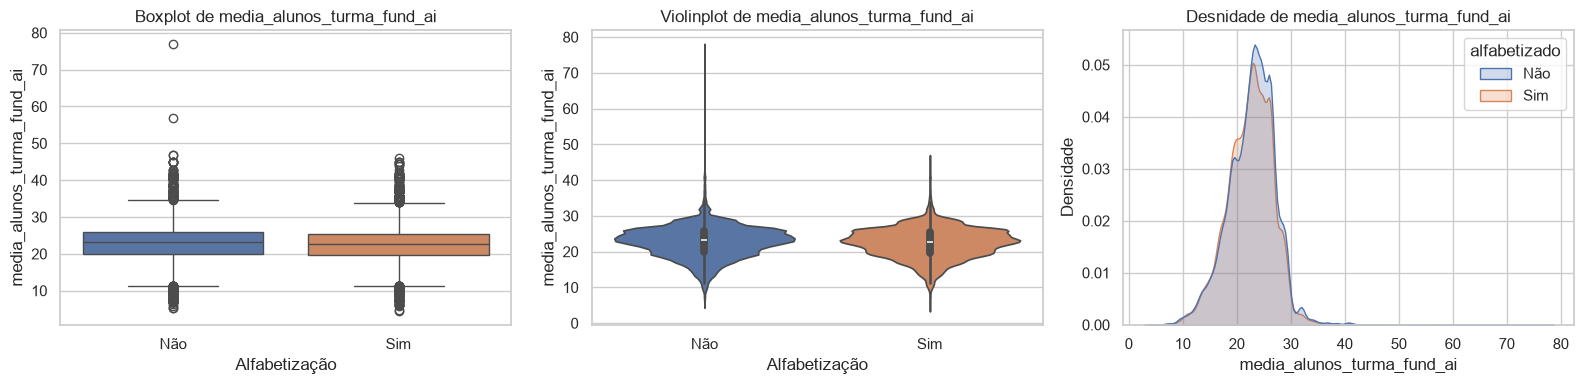

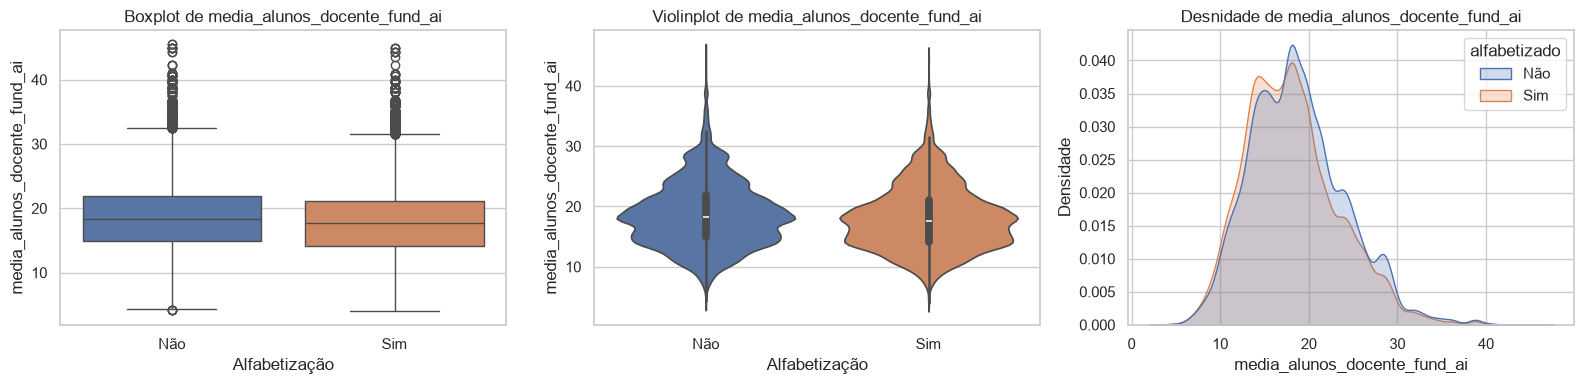

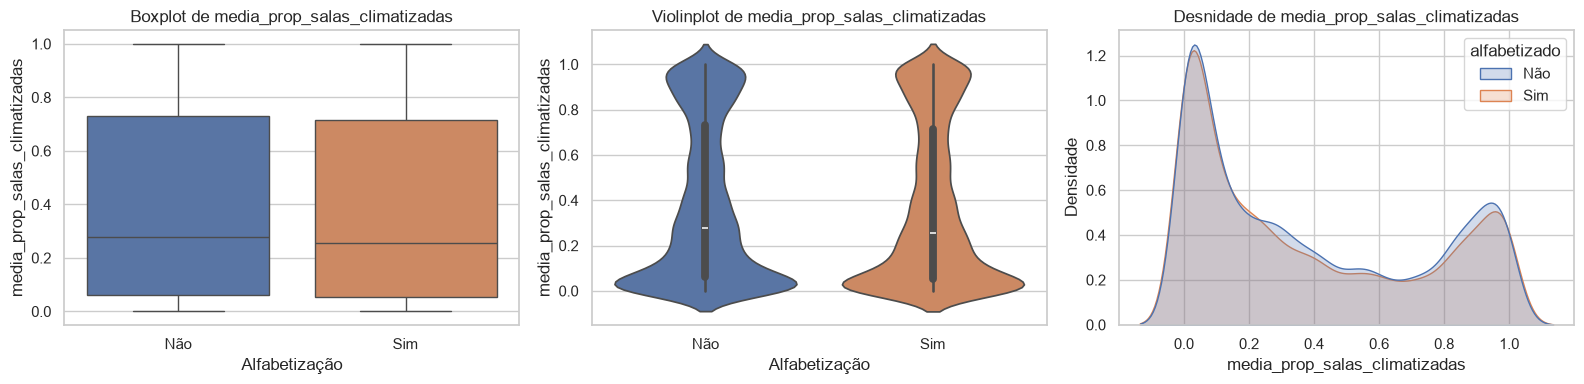

In [29]:
for coluna in df_eda[var_numericas]:
    fig, ax = plt.subplots(1, 3, figsize=(16,4))

    # Boxplot
    sns.boxplot(
        data=df_eda,
        x='alfabetizado',
        y=coluna,
        hue='alfabetizado',
        legend=False,
        ax=ax[0]
    )
    ax[0].set_title(f"Boxplot de {coluna}")
    ax[0].set_xlabel("Alfabetização")
    ax[0].set_ylabel(coluna)

    # Violinplot
    sns.violinplot(
        data=df_eda,
        x='alfabetizado',
        y=coluna,
        hue='alfabetizado',
        legend=False,
        ax=ax[1]
    )
    ax[1].set_title(f"Violinplot de {coluna}")
    ax[1].set_xlabel("Alfabetização")
    ax[1].set_ylabel(coluna)

    # Kdeplot
    sns.kdeplot(
        data=df_eda,
        x=coluna,
        hue='alfabetizado',
        fill=True,
        ax=ax[2]
    )
    ax[2].set_title(f"Desnidade de {coluna}")
    ax[2].set_xlabel(coluna)
    ax[2].set_ylabel("Densidade")

    plt.tight_layout()
    plt.show()

In [30]:
df_eda["alfabetizado_bin"] = (
    df_eda["alfabetizado"]
    .map({
        "Não": 0,
        "Sim": 1
    })
)

In [31]:
colunas_numericas_analise = [
    "pib_per_capita",
    "populacao_2022",
    "area_km2",
    "densidade_demografica",
    "qtd_escolas_censo",
    "prop_escolas_rurais",
    "prop_escolas_agua_potavel",
    "prop_escolas_esgoto_rede",
    "prop_escolas_biblioteca_leitura",
    "prop_escolas_lab_informatica",
    "prop_escolas_internet",
    "prop_escolas_internet_aprendizagem",
    "prop_escolas_banda_larga",
    "prop_escolas_rampas_acessibilidade",
    "media_alunos_turma_fund_ai",
    "media_alunos_docente_fund_ai",
    "media_prop_salas_climatizadas"
]

resumo_target = (
    df_eda
    .groupby("alfabetizado")[colunas_numericas_analise]
    .agg(["mean", "median"])
    .T
)

resumo_target

alfabetizado                                         Não            Sim
pib_per_capita                     mean     49189.790221   49026.510694
                                   median       39206.76       39954.08
populacao_2022                     mean    808866.098174  736018.917328
                                   median       117210.0        89728.0
area_km2                           mean        3093.3012    2394.711845
                                   median        724.279        696.348
densidade_demografica              mean      1151.323783    1077.377848
                                   median         142.94         107.42
qtd_escolas_censo                  mean       174.132415     155.257825
                                   median           62.0           48.0
prop_escolas_rurais                mean         0.284133       0.274982
                                   median       0.166667       0.166667
prop_escolas_agua_potavel          mean         0.968362       0.977591
                                   median            1.0            1.0
prop_escolas_esgoto_rede           mean         0.571558       0.583972
                                   median       0.638095         0.6625
prop_escolas_biblioteca_leitura    mean         0.518242       0.548981
                                   median       0.509524        0.53125
prop_escolas_lab_informatica       mean         0.285805       0.306637
                                   median       0.234043       0.259259
prop_escolas_internet              mean         0.937756       0.954433
                                   median            1.0            1.0
prop_escolas_internet_aprendizagem mean         0.676408       0.715291
                                   median       0.730769       0.770898
prop_escolas_banda_larga           mean         0.866466       0.871558
                                   median       0.943302       0.952381
prop_escolas_rampas_acessibilidade mean         0.581117        0.60707
                                   median       0.598039       0.622449
media_alunos_turma_fund_ai         mean        22.761251      22.459852
                                   median       23.14079      22.791396
media_alunos_docente_fund_ai       mean        18.740422       18.07191
                                   median      18.266974      17.653036
media_prop_salas_climatizadas      mean         0.385628       0.376769
                                   median       0.276816       0.256759

In [32]:
df_eda["faixa_pib"] = pd.qcut(
    df_eda["pib_per_capita"],
    q=5,
    duplicates="drop"
)

taxa_pib = (
    df_eda
    .groupby(
        "faixa_pib",
        observed=True
    )["alfabetizado_bin"]
    .mean()
    .mul(100)
)

taxa_pib

faixa_pib
(7201.699, 19834.014]    49.276618
(19834.014, 32505.64]    47.181574
(32505.64, 48713.16]     49.610120
(48713.16, 67691.3]      50.302245
(67691.3, 842004.6]      48.321447
Name: alfabetizado_bin, dtype: float64

# Variáveis categóricas

In [33]:
colunas_categoricas = [
    "ano",
    "caderno",
    "serie",
    "rede",
    "presenca",
    "preenchimento_caderno",
    "sigla_uf",
    "regiao"
]

In [34]:
df_eda["alfabetizado_bin"] = (
    df_eda["alfabetizado"]
    .map({
        "Não": 0,
        "Sim": 1
    })
)

In [35]:
def analisar_categorica(
    df,
    coluna,
    target_bin="alfabetizado_bin",
    figsize=(10, 5),
    rotacao=0
):
    resumo = (
        df.groupby(coluna, dropna=False)[target_bin]
        .agg(
            quantidade="size",
            taxa_alfabetizacao="mean"
        )
        .reset_index()
    )

    resumo["percentual_amostra"] = (
        resumo["quantidade"]
        / len(df)
        * 100
    ).round(2)

    resumo["taxa_alfabetizacao"] = (
        resumo["taxa_alfabetizacao"]
        * 100
    ).round(2)

    resumo = resumo.sort_values(
        "taxa_alfabetizacao",
        ascending=False
    )

    display(resumo)

    plt.figure(figsize=figsize)

    ax = sns.barplot(
        data=resumo,
        x=coluna,
        y="taxa_alfabetizacao",
        color="#2a9d8f"
    )

    plt.title(
        f"Taxa de alfabetização por {coluna}"
    )
    plt.xlabel(coluna)
    plt.ylabel("Taxa de alfabetização (%)")
    plt.xticks(rotation=rotacao)

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%",
            padding=3
        )

    plt.tight_layout()
    plt.show()

ANÁLISE: ano


,ano,quantidade,taxa_alfabetizacao,percentual_amostra
1,2024,29431,49.62,51.0
0,2023,28281,48.23,49.0


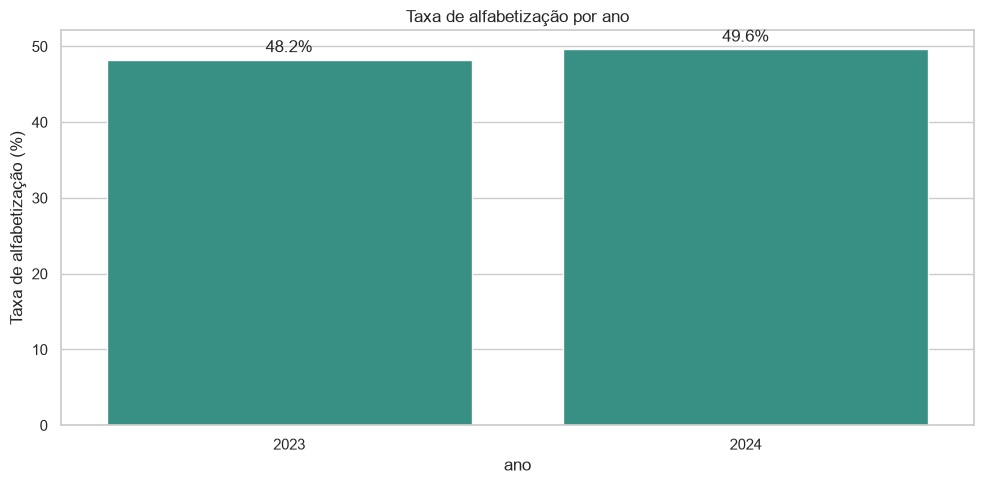

ANÁLISE: caderno


,caderno,quantidade,taxa_alfabetizacao,percentual_amostra
1,10,16227,51.61,28.12
2,11,16134,51.26,27.96
0,1,22814,49.42,39.53
3,12,2537,12.81,4.40


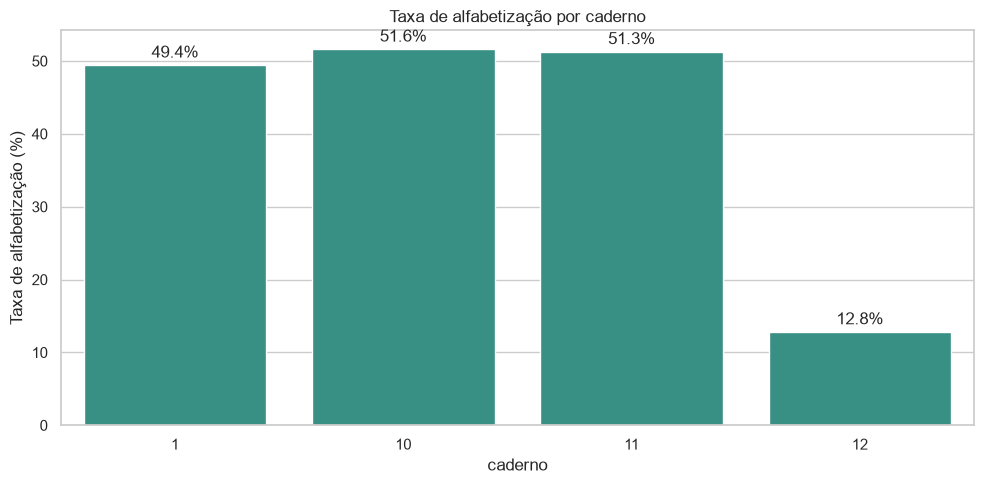

ANÁLISE: serie


,serie,quantidade,taxa_alfabetizacao,percentual_amostra
0,2° ano do Ensino Fundamental,57712,48.94,100.0


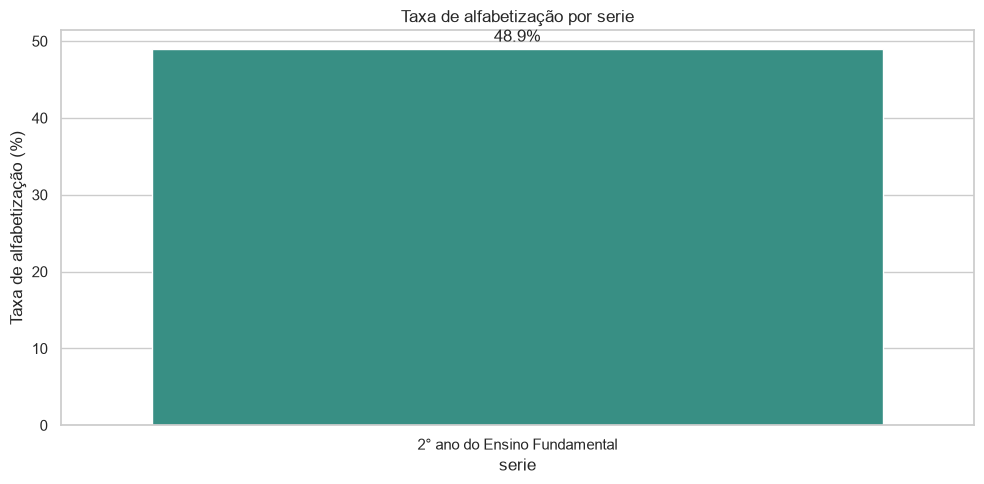

ANÁLISE: rede


,rede,quantidade,taxa_alfabetizacao,percentual_amostra
0,Estadual,6310,51.52,10.93
1,Municipal,51402,48.62,89.07


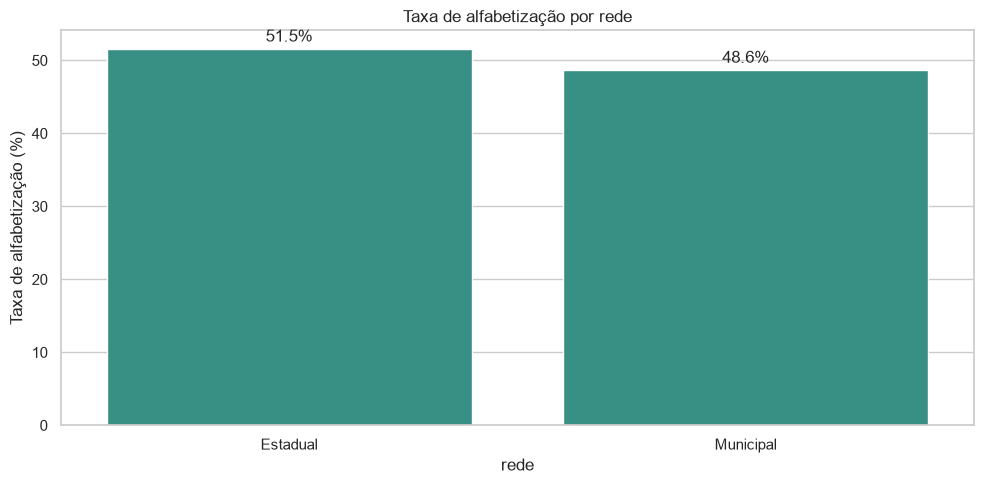

ANÁLISE: presenca


,presenca,quantidade,taxa_alfabetizacao,percentual_amostra
1,Presente,48050,58.78,83.26
0,Ausente,9662,0.00,16.74


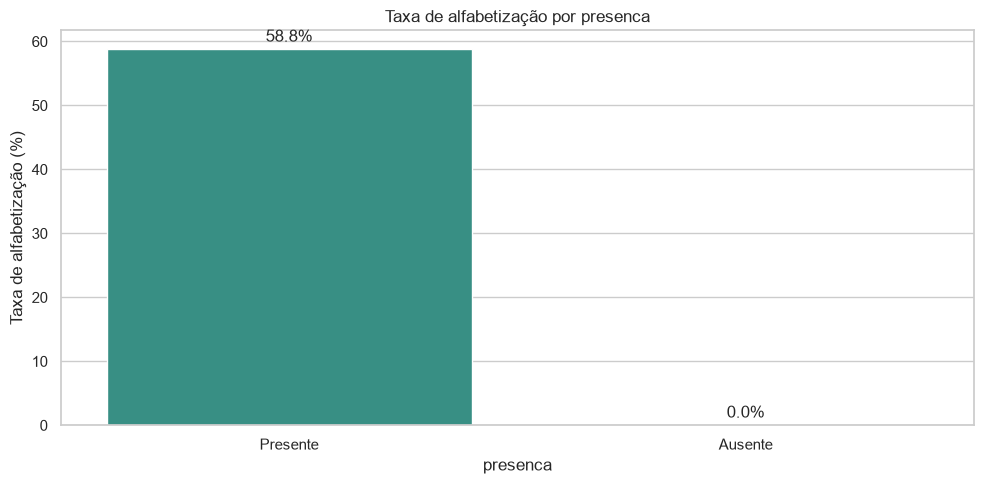

ANÁLISE: preenchimento_caderno


,preenchimento_caderno,quantidade,taxa_alfabetizacao,percentual_amostra
1,Prova preenchida,48021,58.82,83.21
0,Prova não preenchida,9691,0.00,16.79


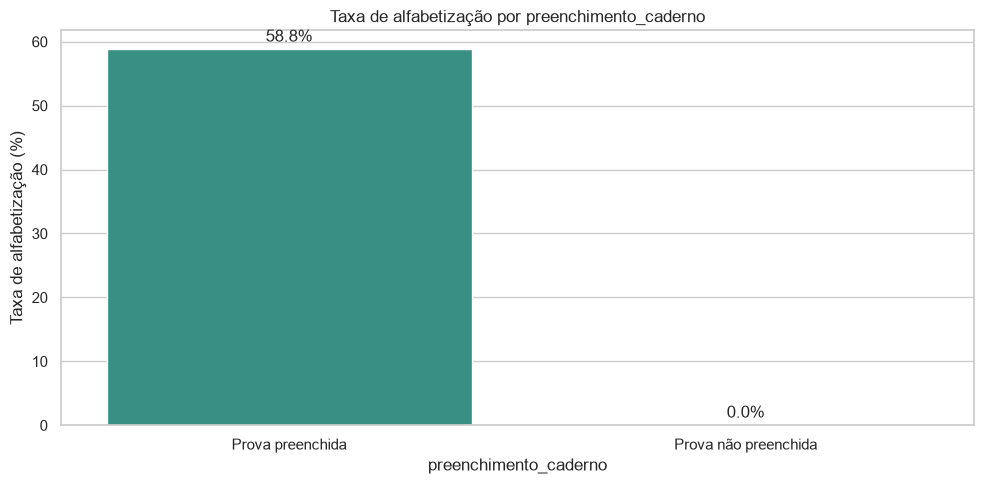

ANÁLISE: sigla_uf


,sigla_uf,quantidade,taxa_alfabetizacao,percentual_amostra
5,CE,2860,81.15,4.96
7,ES,1461,59.41,2.53
17,PR,4392,59.36,7.61
8,GO,2458,58.83,4.26
10,MG,6168,56.96,10.69
15,PE,2391,54.54,4.14
20,RO,710,54.08,1.23
16,PI,1022,51.27,1.77
24,SP,6003,49.53,10.40
9,MA,2237,49.31,3.88


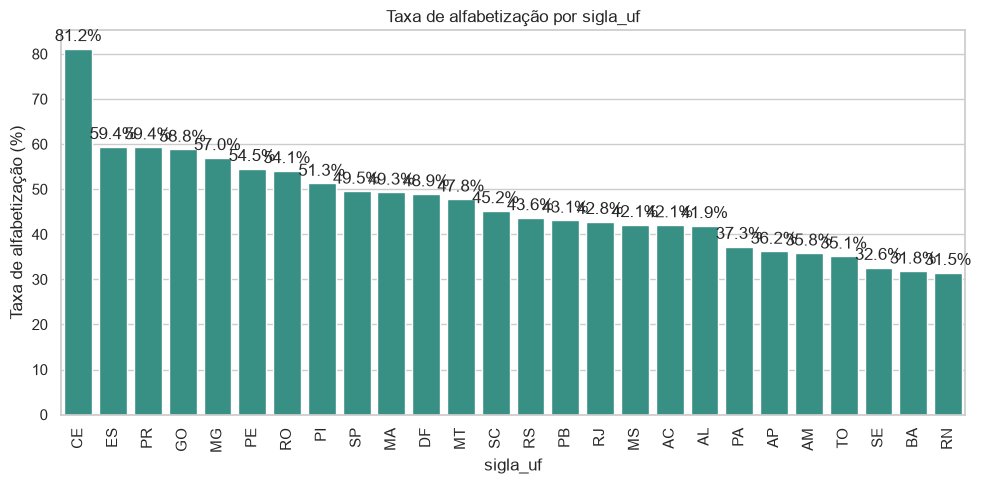

ANÁLISE: regiao


,regiao,quantidade,taxa_alfabetizacao,percentual_amostra
3,Sudeste,18050,51.22,31.28
0,Centro-Oeste,5836,51.15,10.11
4,Sul,10927,50.40,18.93
1,Nordeste,16206,48.93,28.08
2,Norte,6693,38.50,11.60


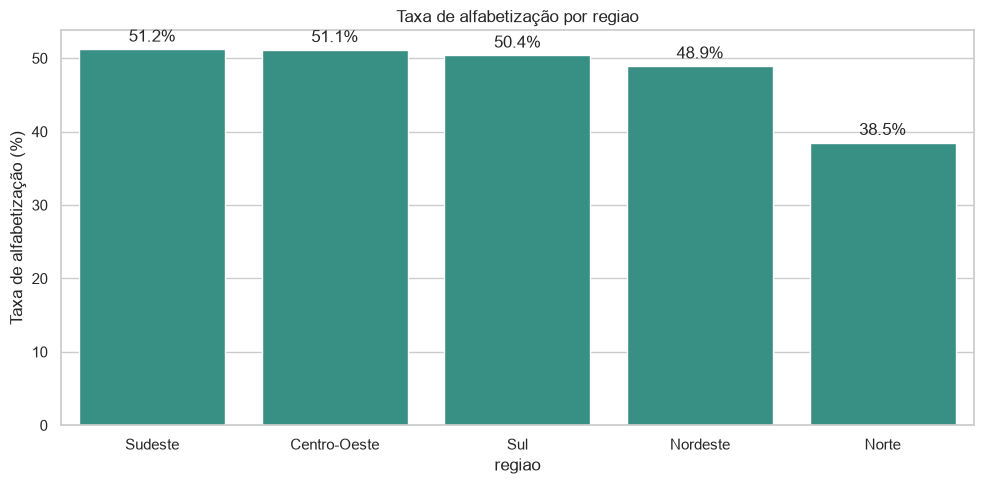

In [36]:
for coluna in colunas_categoricas:
    print("=" * 80)
    print(f"ANÁLISE: {coluna}")
    print("=" * 80)

    rotacao = 90 if coluna == "sigla_uf" else 0

    analisar_categorica(
        df=df_eda,
        coluna=coluna,
        rotacao=rotacao
    )